# Univariate and Bivariate Analysis of Application (External Raitings) Data
- table - application_train.csv
---

__Client's exteral raitings__:
- `EXT_SOURCE_1` - Normalized score from external data source,normalized
- `EXT_SOURCE_2` - Normalized score from external data source,normalized
- `EXT_SOURCE_3` - Normalized score from external data source,normalized

## 0. Data and librarires

In [125]:
import pandas as pd
import numpy as np

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
SRC_PATH = PROJECT_ROOT / 'src'

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from eda_module import (
    plot_quantitative_distribution, plot_categorical_distribution, plot_binary_distribution, 
    plot_binary_vs_binary, plot_categorical_distribution, plot_quantitative_vs_binary,
    plot_categorical_vs_binary
)
from preprocess_module import (
    create_imputed_quantitative_features, filter_high_nans_cols, drop_obs_with_nans_in_low_nan_cols,
    trim_quantitative_var, cap_quantitative_var, categorical_target_summary, bin_quantitative_var
)

In [126]:
app_df = pd.read_csv(r"..\data\raw\application_train.csv")
print(f"Shape of app_df: {app_df.shape}")
app_df.head(10)

Shape of app_df: (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
5,100008,0,Cash loans,M,N,Y,0,99000.0,490495.5,27517.5,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,1.0
6,100009,0,Cash loans,F,Y,Y,1,171000.0,1560726.0,41301.0,...,0,0,0,0,0.0,0.0,0.0,1.0,1.0,2.0
7,100010,0,Cash loans,M,Y,Y,0,360000.0,1530000.0,42075.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
8,100011,0,Cash loans,F,N,Y,0,112500.0,1019610.0,33826.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
9,100012,0,Revolving loans,M,N,Y,0,135000.0,405000.0,20250.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


## 1. EXT_SOURCE_1
Normalized score from external data source, normalized

In [127]:
app_df['EXT_SOURCE_1'].describe()

count    134133.000000
mean          0.502130
std           0.211062
min           0.014568
25%           0.334007
50%           0.505998
75%           0.675053
max           0.962693
Name: EXT_SOURCE_1, dtype: float64

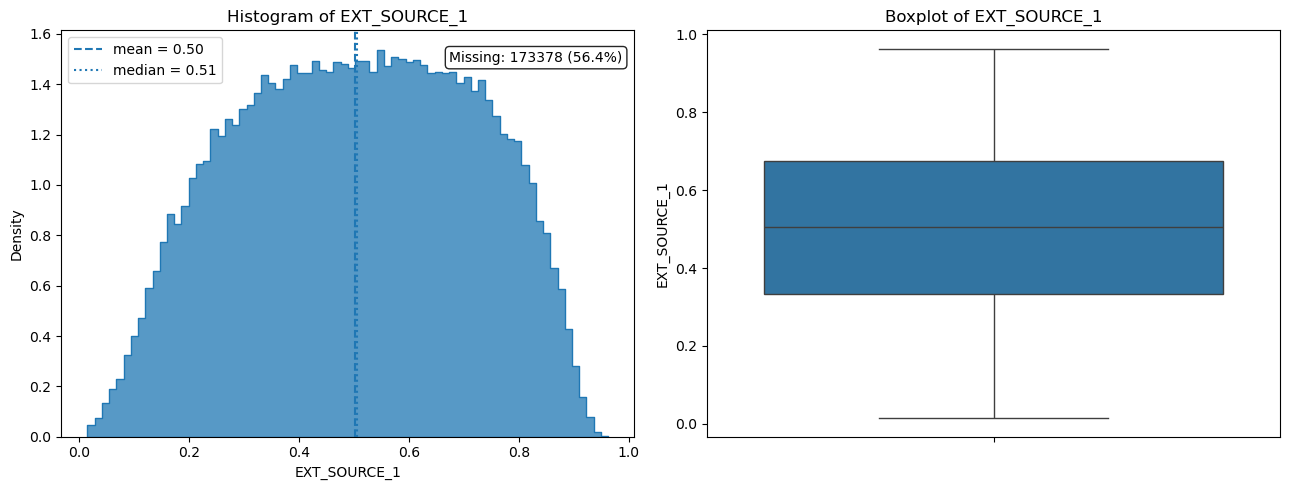

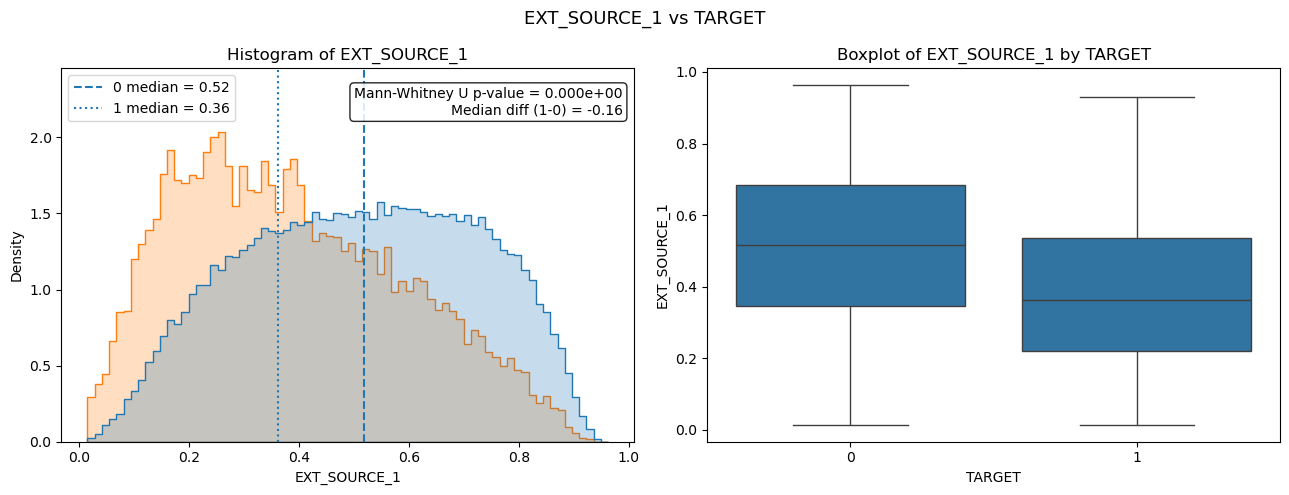

In [128]:
plot_quantitative_distribution(df=app_df, quant_var='EXT_SOURCE_1')
plot_quantitative_vs_binary(df=app_df, quant_var='EXT_SOURCE_1', target_var='TARGET')

The distributions are clearly different from each other, but the columns has over 56% NANs.

In [129]:
app_df['EXT_SOURCE_1_missing'] = np.where(
    app_df['EXT_SOURCE_1'].isna(),
    1,
    0
)
app_df['EXT_SOURCE_1_missing'].value_counts()

EXT_SOURCE_1_missing
1    173378
0    134133
Name: count, dtype: int64

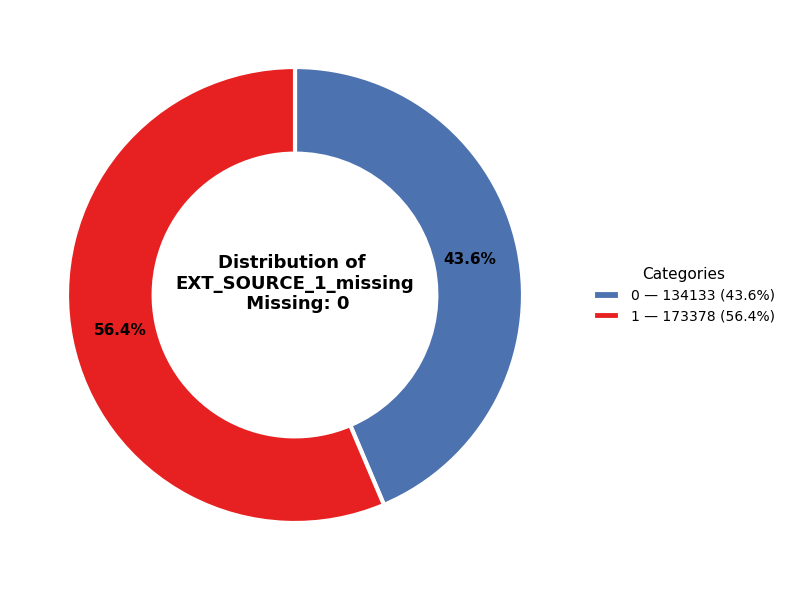

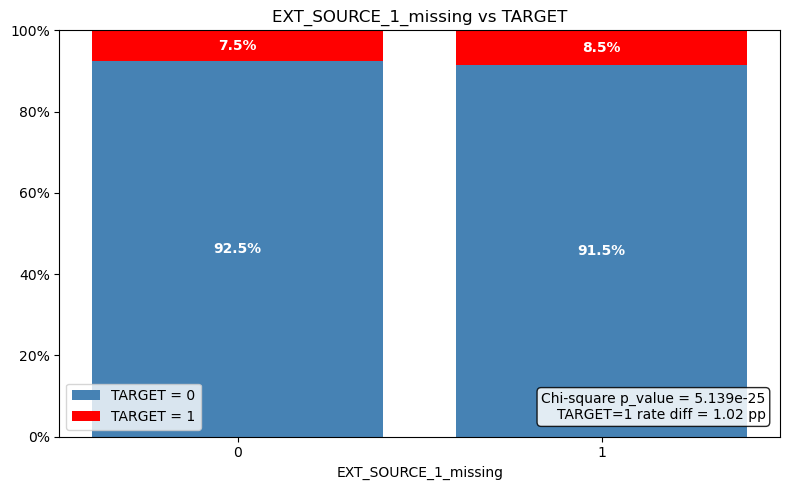

In [130]:
plot_binary_distribution(df=app_df, binary_var='EXT_SOURCE_1_missing')
plot_binary_vs_binary(df=app_df, binary_var='EXT_SOURCE_1_missing', target_var='TARGET')

Clients with with NAN in `EXT_SOURCE_1` have higher risk. 

In [131]:
app_df['NAME_INCOME_TYPE_grouped'] = np.where(
    app_df['NAME_INCOME_TYPE'].isin(values=['Pensioner', 'Unemployed', 'Student', 'Maternity leave']),
    'Pensioner',
    np.where(
        app_df['NAME_INCOME_TYPE'].isin(['Working', 'Businessman']),
        'Working',
        app_df['NAME_INCOME_TYPE']
    )
)

In [132]:
ext_1_imputation_spec = {
    "EXT_SOURCE_1_imp_global": {
        "metod": "median",
        "group_levels": []
    },
    "EXT_SOURCE_1_imp_income_type": {
        "metod": "median",
        "group_levels": [['NAME_INCOME_TYPE_grouped']]
    },
    "EXT_SOURCE_1_imp_income_type_gender": {
        "metod": "median",
        "group_levels": [['NAME_INCOME_TYPE_grouped', 'CODE_GENDER'], ['NAME_INCOME_TYPE_grouped']]
    },
}

df_imp, ext_1_summary = create_imputed_quantitative_features(
    df=app_df,
    value_col='EXT_SOURCE_1',
    specs=ext_1_imputation_spec,
    add_invalid_flag=False,
    add_clean_col=False,
    return_summary=True
)

ext_1_summary

,output_col,method,n_invalid,missing_before_imputation,filled_by_hierarchy,filled_by_global,missing_after_imputation,group_levels,step,group_level,filled_count
0,EXT_SOURCE_1_imp_global,median,0.0,173378.0,0.0,173378.0,0.0,[],NaN,NaN,NaN
1,EXT_SOURCE_1_imp_income_type,median,0.0,173378.0,173378.0,0.0,0.0,[['NAME_INCOME_TYPE_grouped']],NaN,NaN,NaN
2,EXT_SOURCE_1_imp_income_type,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,"(NAME_INCOME_TYPE_grouped,)",173378.0
3,EXT_SOURCE_1_imp_income_type_gender,median,0.0,173378.0,173378.0,0.0,0.0,"[['NAME_INCOME_TYPE_grouped', 'CODE_GENDER'], ...",NaN,NaN,NaN
4,EXT_SOURCE_1_imp_income_type_gender,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,"(NAME_INCOME_TYPE_grouped, CODE_GENDER)",173378.0
5,EXT_SOURCE_1_imp_income_type_gender,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,"(NAME_INCOME_TYPE_grouped,)",0.0


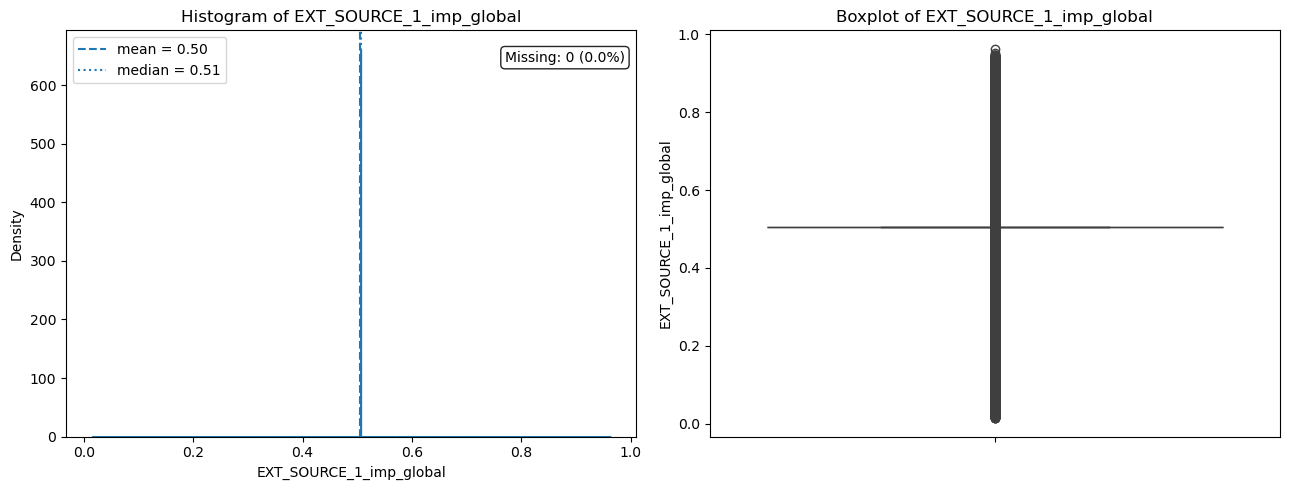

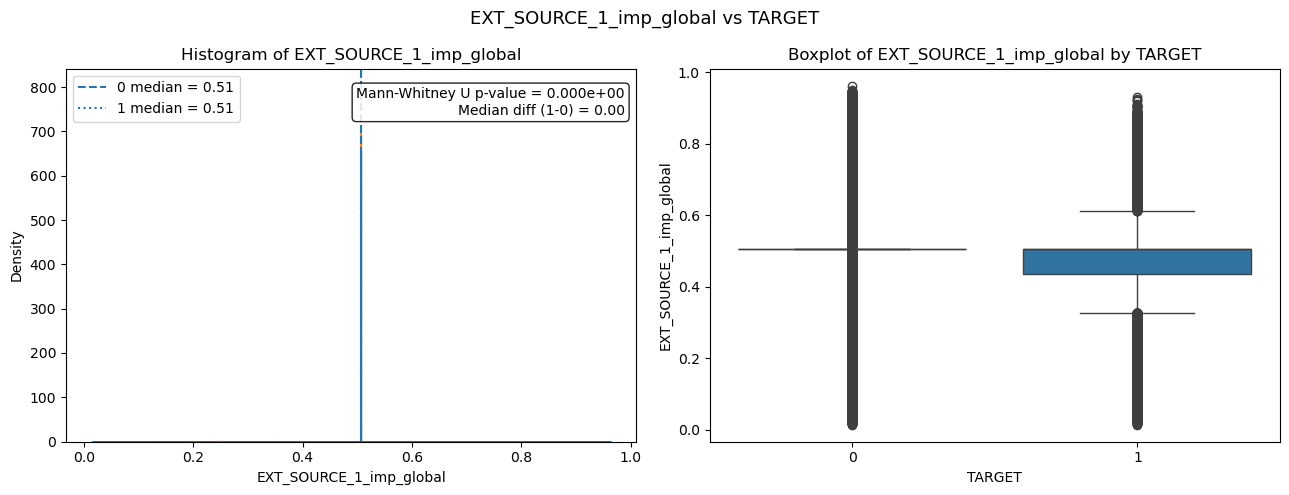

In [133]:
plot_quantitative_distribution(df=df_imp, quant_var='EXT_SOURCE_1_imp_global')
plot_quantitative_vs_binary(df=df_imp, quant_var='EXT_SOURCE_1_imp_global', target_var='TARGET')

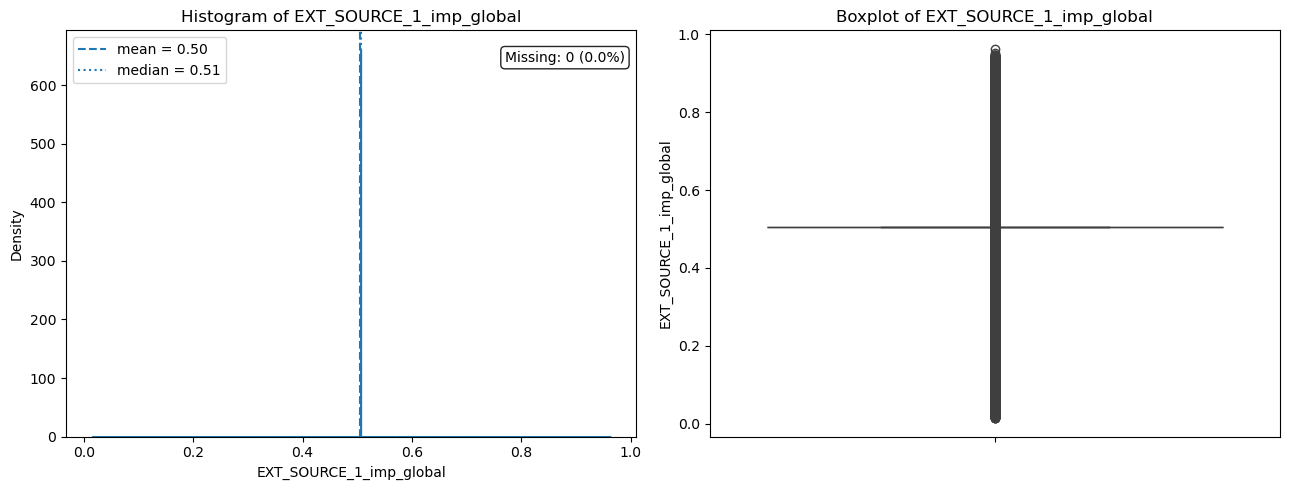

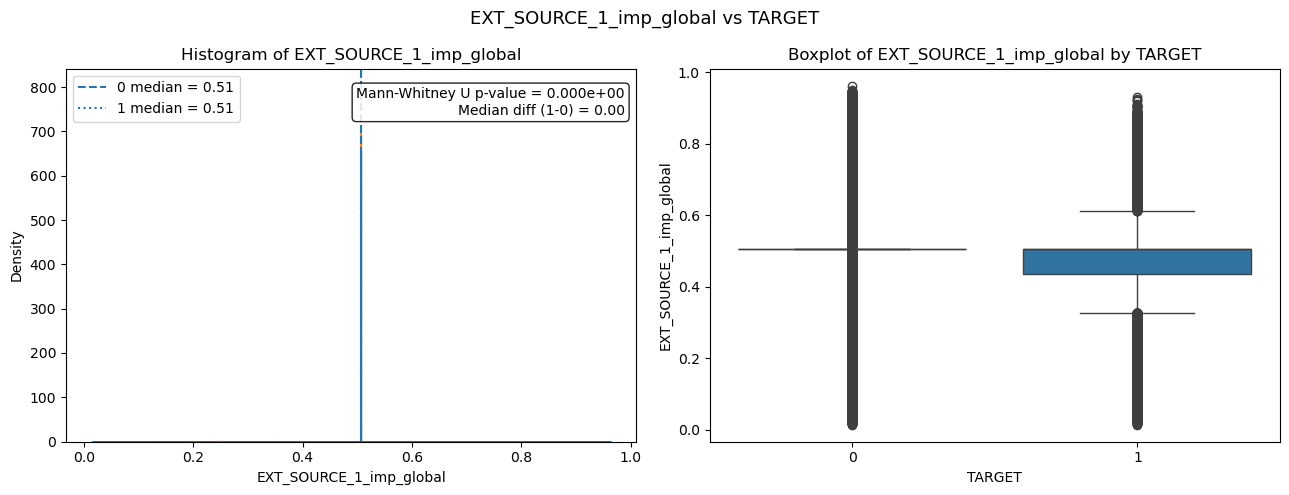

In [134]:
plot_quantitative_distribution(df=df_imp, quant_var='EXT_SOURCE_1_imp_global')
plot_quantitative_vs_binary(df=df_imp, quant_var='EXT_SOURCE_1_imp_global', target_var='TARGET')

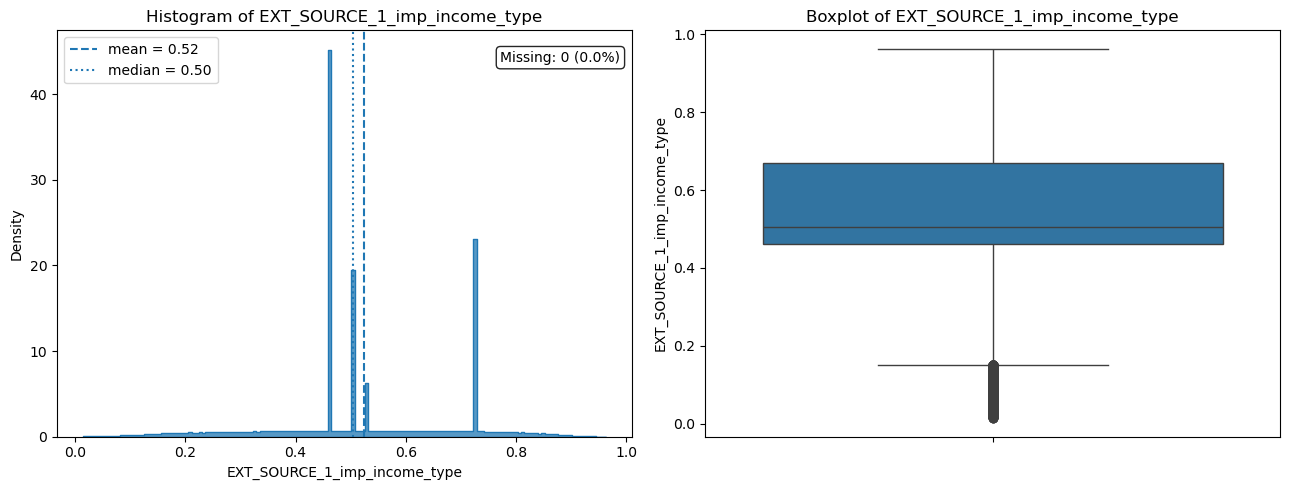

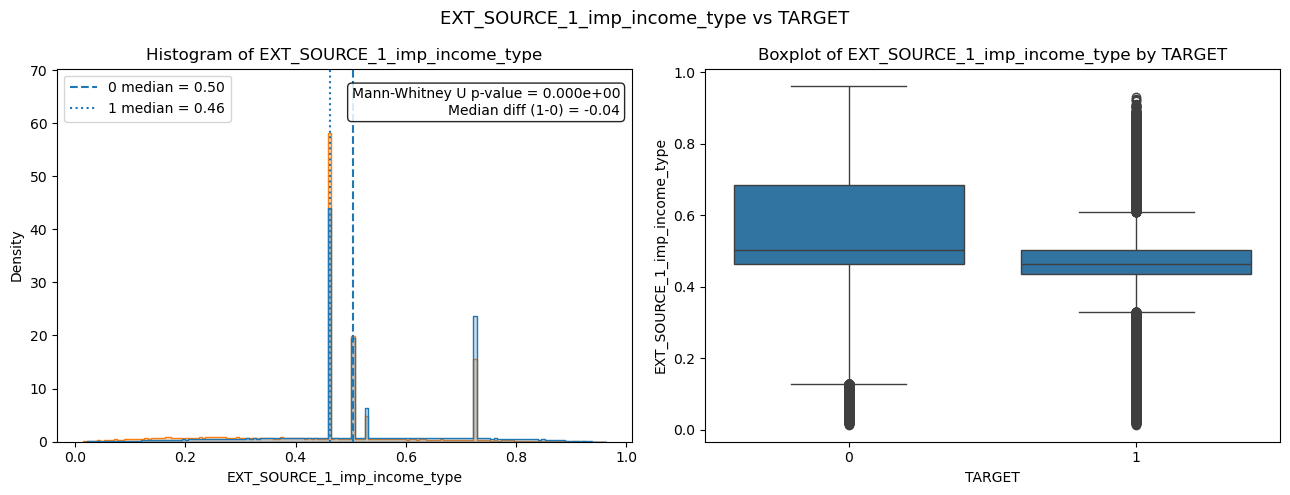

In [135]:
plot_quantitative_distribution(df=df_imp, quant_var='EXT_SOURCE_1_imp_income_type')
plot_quantitative_vs_binary(df=df_imp, quant_var='EXT_SOURCE_1_imp_income_type', target_var='TARGET')

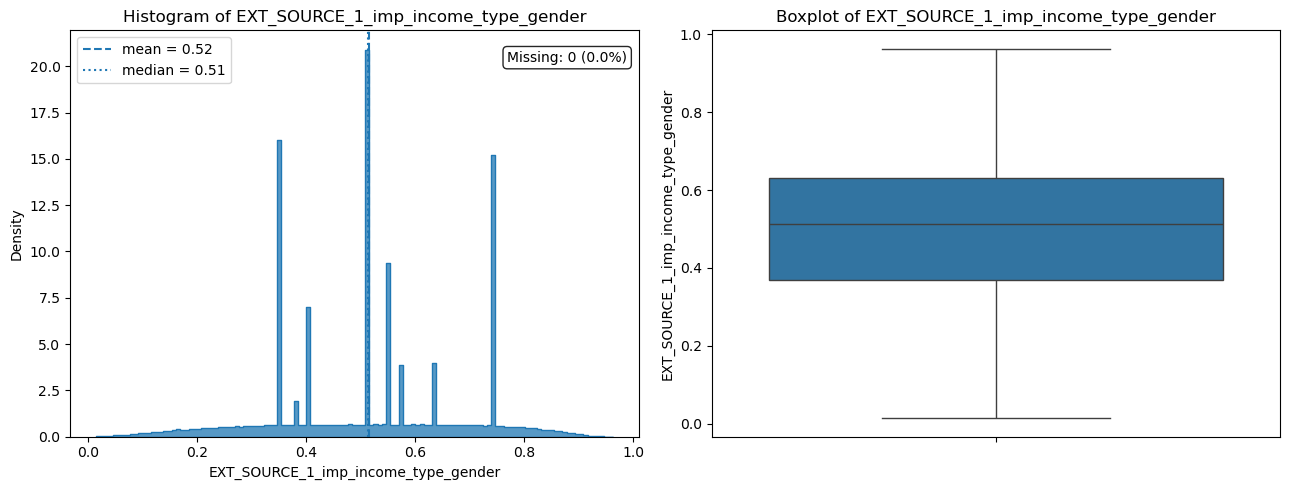

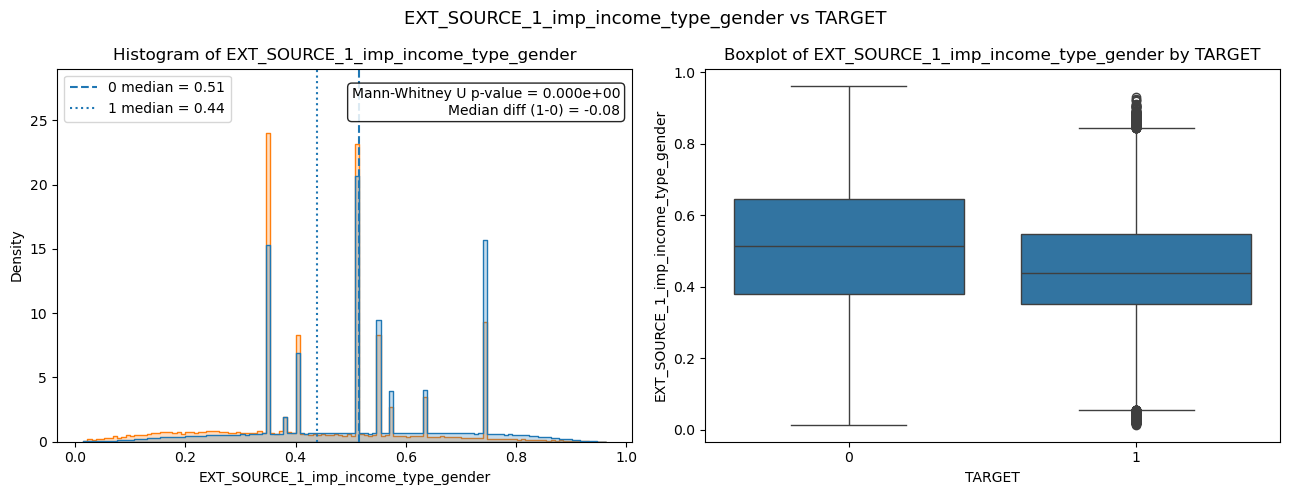

In [136]:
plot_quantitative_distribution(df=df_imp, quant_var='EXT_SOURCE_1_imp_income_type_gender')
plot_quantitative_vs_binary(df=df_imp, quant_var='EXT_SOURCE_1_imp_income_type_gender', target_var='TARGET')

It looks like imputation by `INCOME_TYPE` and `GENDER_CODE` group medians perserved the difference in distributions. It will be used in modeling.

In [137]:
binned_df, ext_source_1_summary = bin_quantitative_var(
    df = app_df,
    quant_var='EXT_SOURCE_1',
    quantiles_bins=True,
    target_var='TARGET',
    missing_as_category=True,
    return_binned_quantiles=False,
    return_summary=True,
    return_df=True
)

ext_source_1_summary

,feature,binned_column,binning_type,bin,count,share,n_target_1,n_target_0,target_rate
0,EXT_SOURCE_1,EXT_SOURCE_1_binned_quantiles,quantiles,Q1,26827,0.087239,3911,22916,0.145786
1,EXT_SOURCE_1,EXT_SOURCE_1_binned_quantiles,quantiles,Q2,26826,0.087236,2344,24482,0.087378
2,EXT_SOURCE_1,EXT_SOURCE_1_binned_quantiles,quantiles,Q3,26827,0.087239,1706,25121,0.063593
3,EXT_SOURCE_1,EXT_SOURCE_1_binned_quantiles,quantiles,Q4,26826,0.087236,1277,25549,0.047603
4,EXT_SOURCE_1,EXT_SOURCE_1_binned_quantiles,quantiles,Q5,26827,0.087239,816,26011,0.030417
5,EXT_SOURCE_1,EXT_SOURCE_1_binned_quantiles,quantiles,Missing,173378,0.563811,14771,158607,0.085195


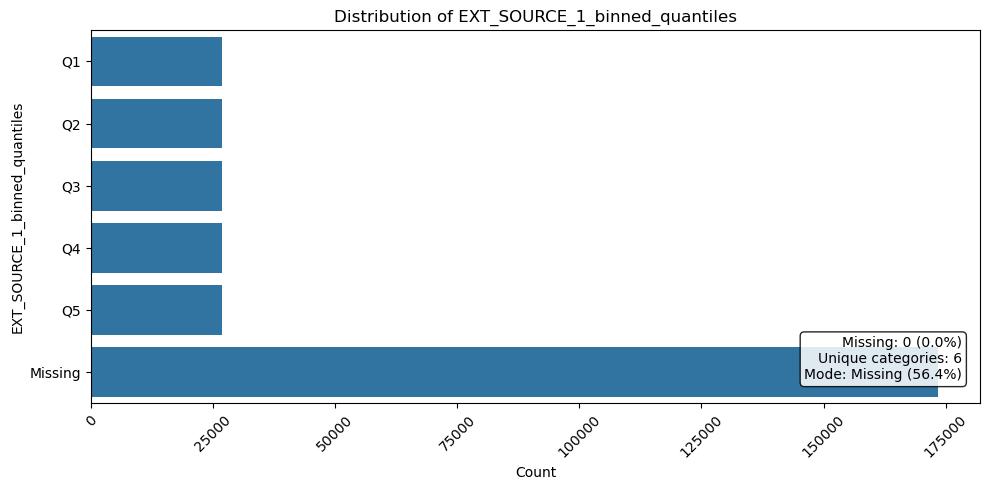

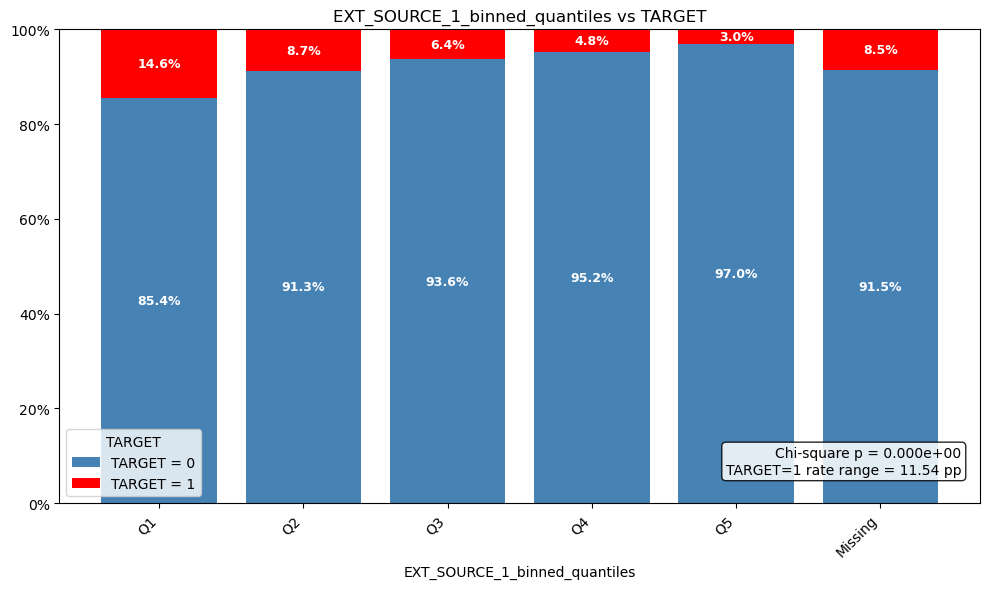

In [138]:
plot_categorical_distribution(df=binned_df, cat_var='EXT_SOURCE_1_binned_quantiles', respect_category_order=True)
plot_categorical_vs_binary(df=binned_df, cat_var='EXT_SOURCE_1_binned_quantiles', target_var='TARGET', respect_category_order=True)

In [139]:
binned_df, ext_source_1_imp_income_gender_summary = bin_quantitative_var(
    df = df_imp,
    quant_var='EXT_SOURCE_1_imp_income_type_gender',
    quantiles_bins=True,
    target_var='TARGET',
    missing_as_category=False,
    return_binned_quantiles=False,
    return_summary=True,
    return_df=True
)

ext_source_1_imp_income_gender_summary

,feature,binned_column,binning_type,bin,count,share,n_target_1,n_target_0,target_rate
0,EXT_SOURCE_1_imp_income_type_gender,EXT_SOURCE_1_imp_income_type_gender_binned_qua...,quantiles,Q1,73478,0.238944,9326,64152,0.126922
1,EXT_SOURCE_1_imp_income_type_gender,EXT_SOURCE_1_imp_income_type_gender_binned_qua...,quantiles,Q2,49527,0.161058,4061,45466,0.081996
2,EXT_SOURCE_1_imp_income_type_gender,EXT_SOURCE_1_imp_income_type_gender_binned_qua...,quantiles,Q3,75829,0.246590,6297,69532,0.083042
3,EXT_SOURCE_1_imp_income_type_gender,EXT_SOURCE_1_imp_income_type_gender_binned_qua...,quantiles,Q4,47175,0.153409,2584,44591,0.054775
4,EXT_SOURCE_1_imp_income_type_gender,EXT_SOURCE_1_imp_income_type_gender_binned_qua...,quantiles,Q5,61502,0.199999,2557,58945,0.041576


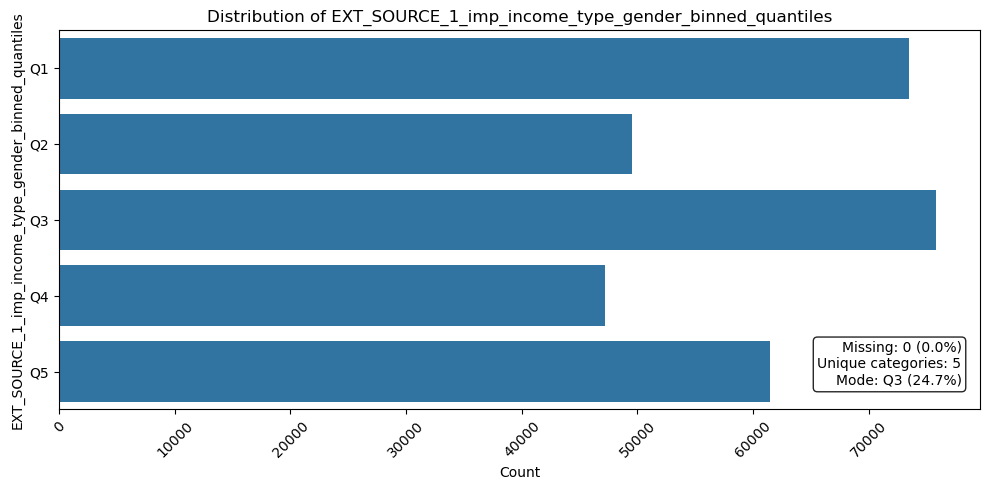

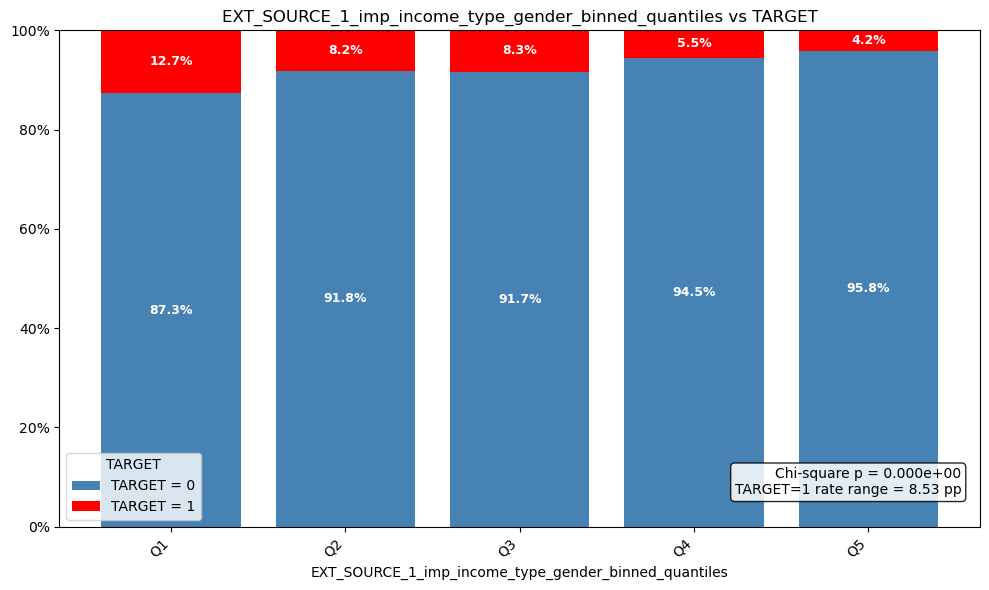

In [140]:
plot_categorical_distribution(df=binned_df, cat_var='EXT_SOURCE_1_imp_income_type_gender_binned_quantiles', respect_category_order=True)
plot_categorical_vs_binary(df=binned_df, cat_var='EXT_SOURCE_1_imp_income_type_gender_binned_quantiles', target_var='TARGET', respect_category_order=True)

## 2. EXT_SOURCE_2
Normalized score from external data source, normalized

In [141]:
app_df['EXT_SOURCE_2'].describe()

count    3.068510e+05
mean     5.143927e-01
std      1.910602e-01
min      8.173617e-08
25%      3.924574e-01
50%      5.659614e-01
75%      6.636171e-01
max      8.549997e-01
Name: EXT_SOURCE_2, dtype: float64

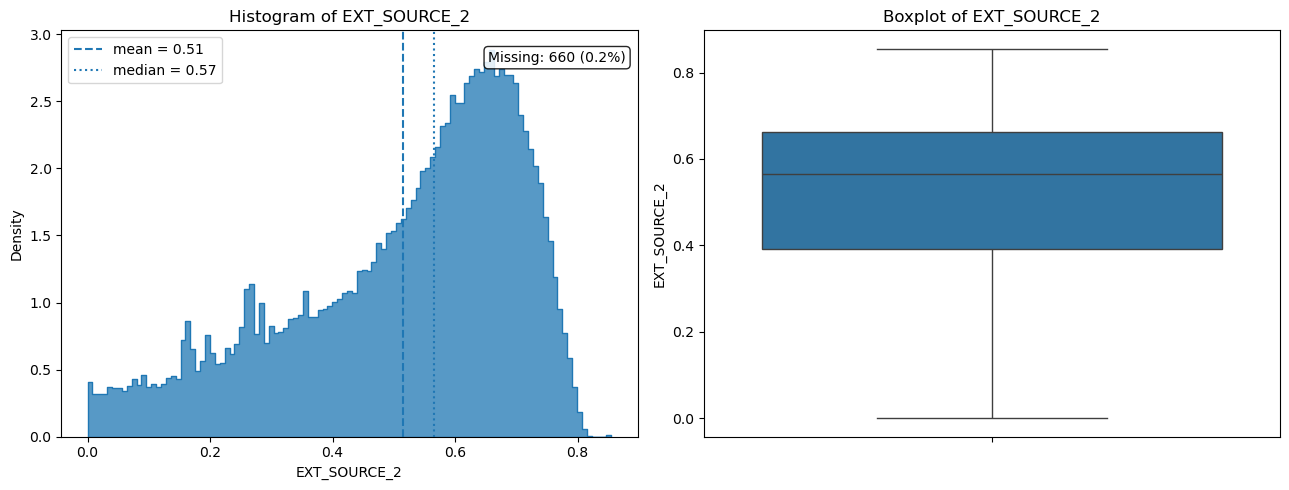

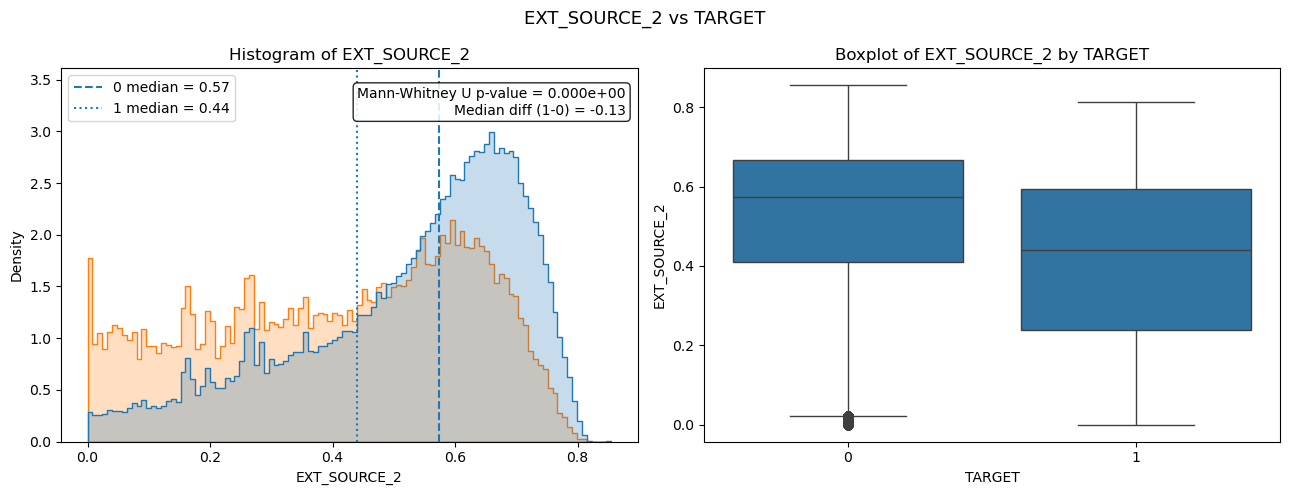

In [142]:
plot_quantitative_distribution(df=app_df, quant_var='EXT_SOURCE_2')
plot_quantitative_vs_binary(df=app_df, quant_var='EXT_SOURCE_2', target_var='TARGET')

The distributions are clearly different from each other.

In [143]:
app_df['EXT_SOURCE_2_missing'] = np.where(
    app_df['EXT_SOURCE_2'].isna(),
    1,
    0
)
app_df['EXT_SOURCE_2_missing'].value_counts()

EXT_SOURCE_2_missing
0    306851
1       660
Name: count, dtype: int64

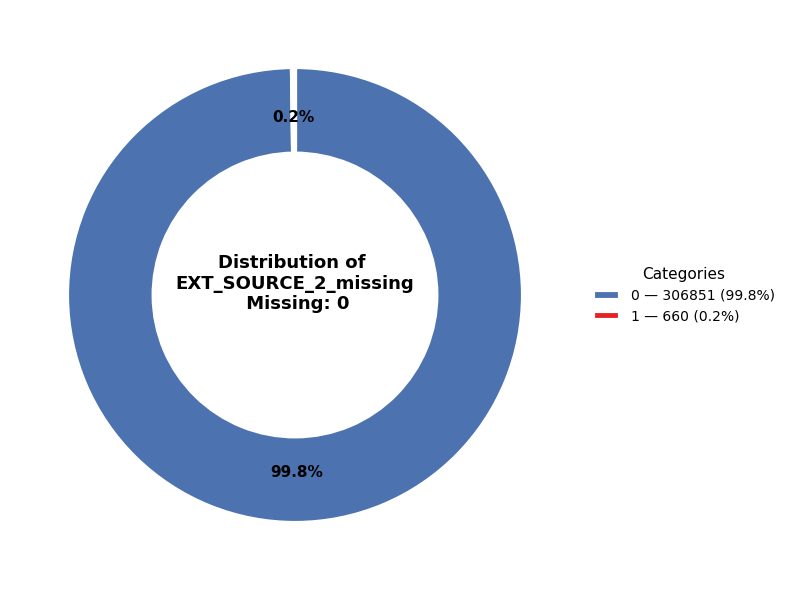

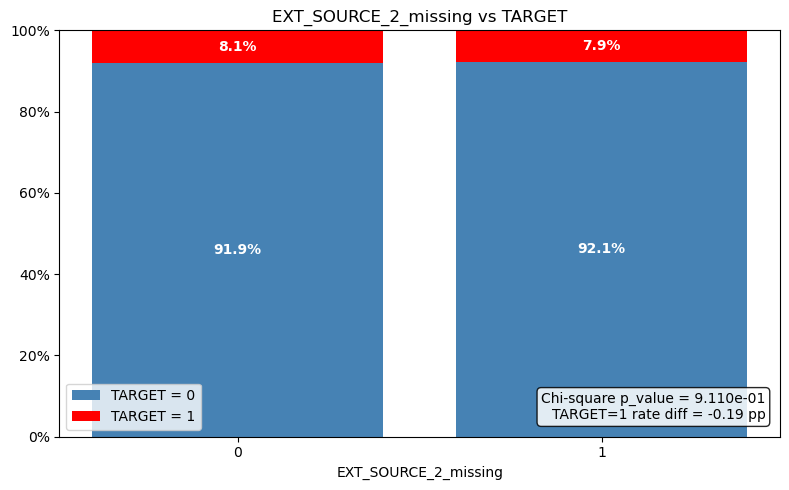

In [144]:
plot_binary_distribution(df=app_df, binary_var='EXT_SOURCE_2_missing')
plot_binary_vs_binary(df=app_df, binary_var='EXT_SOURCE_2_missing', target_var='TARGET')

`EXT_SOURCE_2_missing` doesn't hold important information.

In [145]:
binned_df, ext_source_2_summary = bin_quantitative_var(
    df = app_df,
    quant_var='EXT_SOURCE_2',
    quantiles_bins=True,
    target_var='TARGET',
    missing_as_category=True,
    return_binned_quantiles=False,
    return_summary=True,
    return_df=True
)

ext_source_2_summary

,feature,binned_column,binning_type,bin,count,share,n_target_1,n_target_0,target_rate
0,EXT_SOURCE_2,EXT_SOURCE_2_binned_quantiles,quantiles,Q1,61371,0.199573,9337,52034,0.152140
1,EXT_SOURCE_2,EXT_SOURCE_2_binned_quantiles,quantiles,Q2,61371,0.199573,5622,55749,0.091607
2,EXT_SOURCE_2,EXT_SOURCE_2_binned_quantiles,quantiles,Q3,61371,0.199573,4320,57051,0.070392
3,EXT_SOURCE_2,EXT_SOURCE_2_binned_quantiles,quantiles,Q4,61377,0.199593,3293,58084,0.053652
4,EXT_SOURCE_2,EXT_SOURCE_2_binned_quantiles,quantiles,Q5,61361,0.199541,2201,59160,0.035870
5,EXT_SOURCE_2,EXT_SOURCE_2_binned_quantiles,quantiles,Missing,660,0.002146,52,608,0.078788


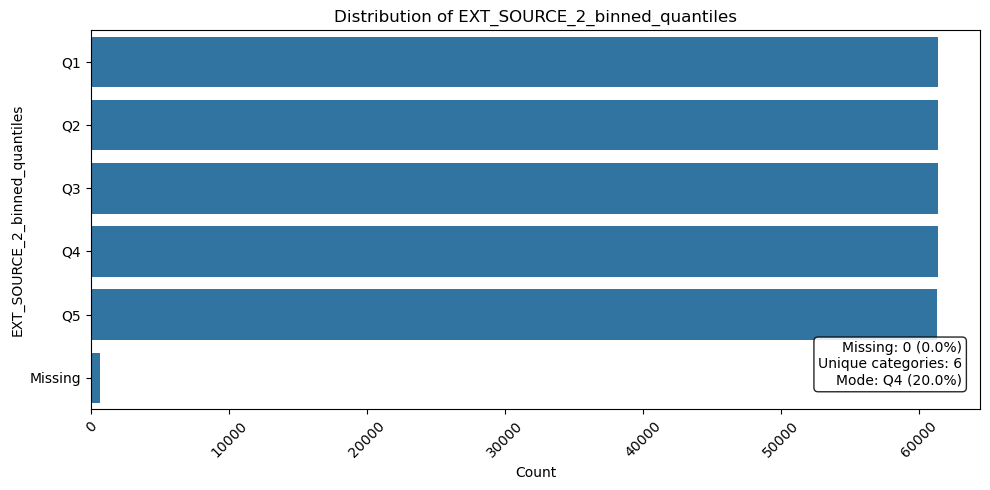

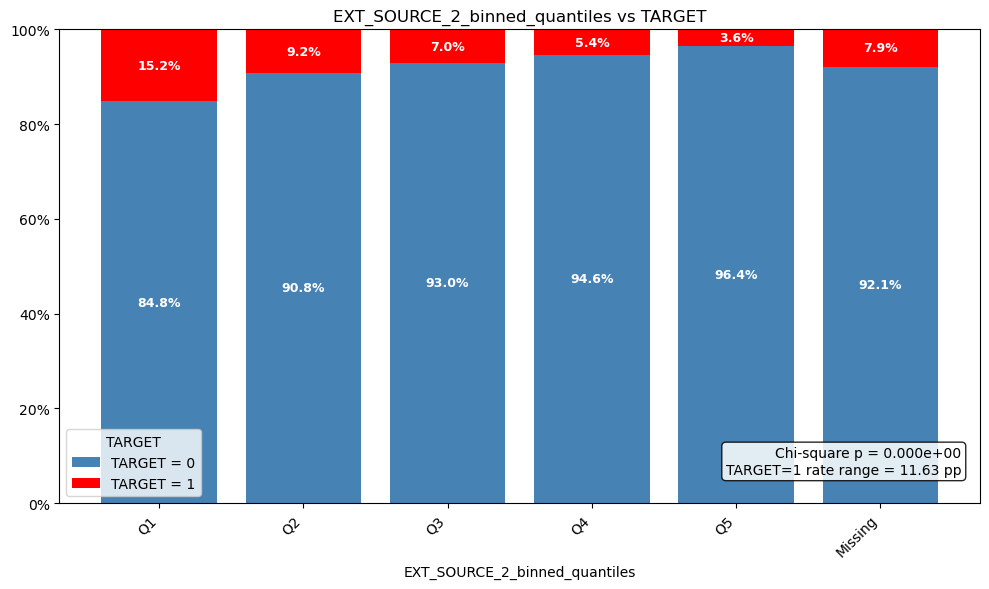

In [146]:
plot_categorical_distribution(df=binned_df, cat_var='EXT_SOURCE_2_binned_quantiles', respect_category_order=True)
plot_categorical_vs_binary(df=binned_df, cat_var='EXT_SOURCE_2_binned_quantiles', target_var='TARGET', respect_category_order=True)

## 3. EXT_SOURCE_3
Normalized score from external data source, normalized

In [147]:
app_df['EXT_SOURCE_3'].describe()

count    246546.000000
mean          0.510853
std           0.194844
min           0.000527
25%           0.370650
50%           0.535276
75%           0.669057
max           0.896010
Name: EXT_SOURCE_3, dtype: float64

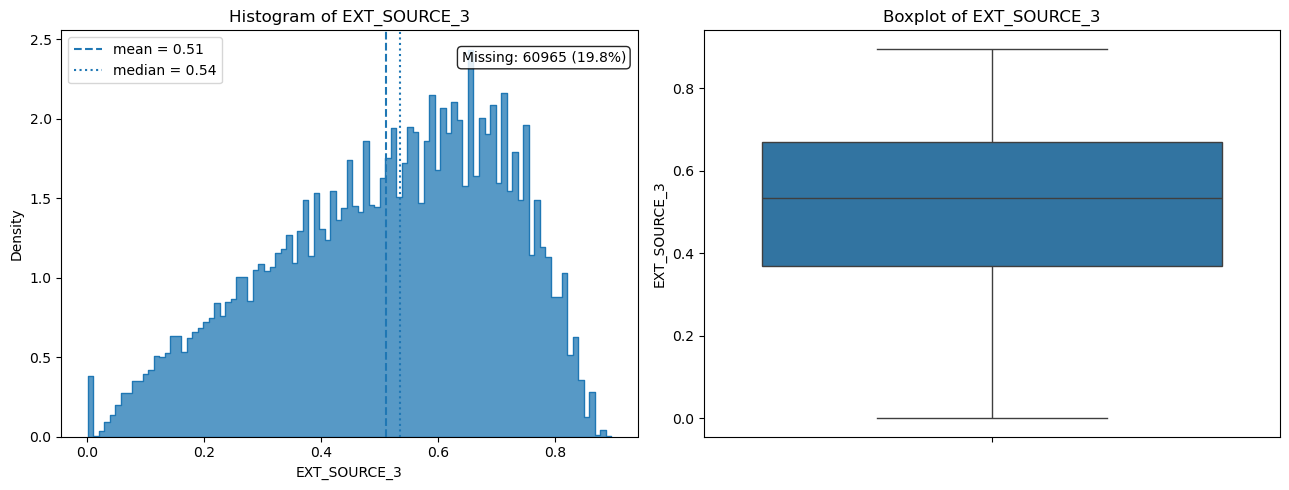

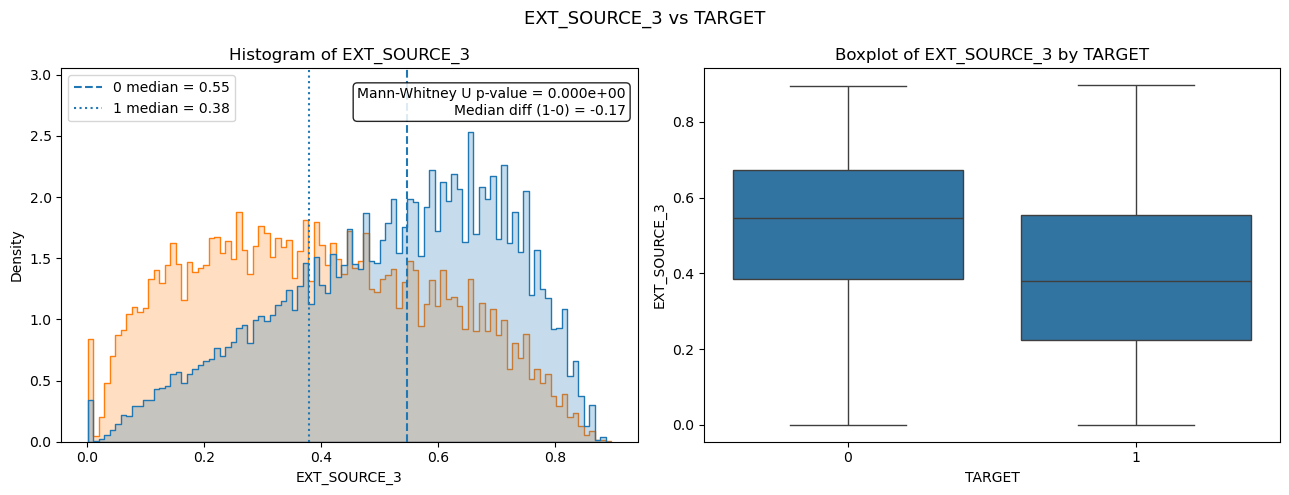

In [148]:
plot_quantitative_distribution(df=app_df, quant_var='EXT_SOURCE_3')
plot_quantitative_vs_binary(df=app_df, quant_var='EXT_SOURCE_3', target_var='TARGET')

The distributions are clearly different from each other, but the columns has over 20% NANs.

In [149]:
app_df['EXT_SOURCE_3_missing'] = np.where(
    app_df['EXT_SOURCE_2'].isna(),
    1,
    0
)
app_df['EXT_SOURCE_3_missing'].value_counts()

EXT_SOURCE_3_missing
0    306851
1       660
Name: count, dtype: int64

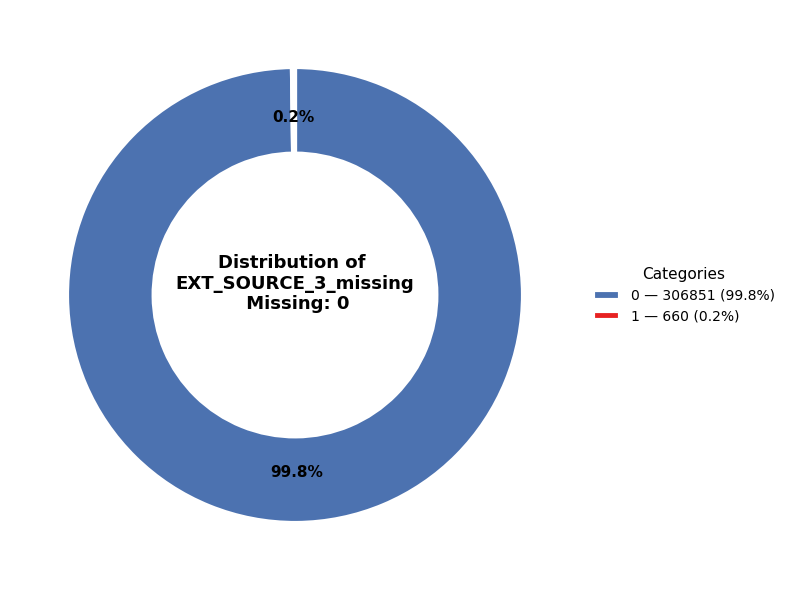

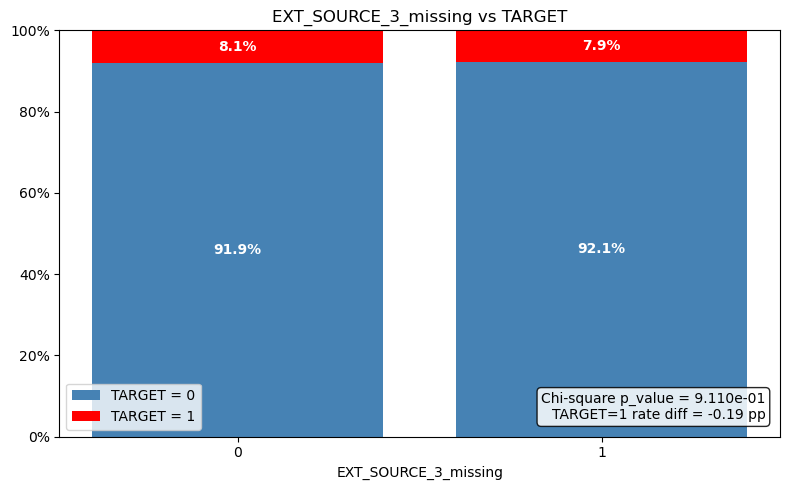

In [150]:
plot_binary_distribution(df=app_df, binary_var='EXT_SOURCE_3_missing')
plot_binary_vs_binary(df=app_df, binary_var='EXT_SOURCE_3_missing', target_var='TARGET')

The missing flag holds importat information, it will be used in modeling.

In [151]:
df_imp['NAME_EDUCATION_TYPE_grouped'] = np.where(
    df_imp['NAME_EDUCATION_TYPE'].isin(['Higher education', 'Academic degree']),
    'Higher education / Academic degree',
    df_imp['NAME_EDUCATION_TYPE']
)
df_imp['NAME_EDUCATION_TYPE_grouped'].value_counts()

NAME_EDUCATION_TYPE_grouped
Secondary / secondary special         218391
Higher education / Academic degree     75027
Incomplete higher                      10277
Lower secondary                         3816
Name: count, dtype: int64

In [152]:
df_imp['OCCUPATION_TYPE_grouped'] = np.where(
    df_imp['OCCUPATION_TYPE'].isin(['Core staff', 'Managers', 'High skill tech staff', 'IT staff']),
    'Core / Managers Hihg skill tech / IT',
    np.where(
        df_imp['OCCUPATION_TYPE'].isin(['HR staff', 'Realty agents', 'Secretaries']),
        'HR / Realty agents / Secretaries',
        np.where(
            df_imp['OCCUPATION_TYPE'].isin(['Waiters/barmen staff', 'Security staff', 'Laborers', 'Cooking staff']),
            'Waiters/barmen / Security / Laborers / Cooking',
            np.where(
                df_imp['OCCUPATION_TYPE'].isin(['Private service staff', 'Medicine staff']),
                'Private service / Medicine staff',
                np.where(
                    df_imp['OCCUPATION_TYPE'].isin(['Sales staff', 'Cleaning staff']),
                    'Sales staff / Cleaning staff',
                    df_imp['OCCUPATION_TYPE']
                )
            )
        )
    )
)
df_imp['OCCUPATION_TYPE_grouped'].value_counts()

OCCUPATION_TYPE_grouped
Waiters/barmen / Security / Laborers / Cooking    69201
Core / Managers Hihg skill tech / IT              60847
Sales staff / Cleaning staff                      36755
Drivers                                           18603
Private service / Medicine staff                  11189
Accountants                                        9813
HR / Realty agents / Secretaries                   2619
Low-skill Laborers                                 2093
Name: count, dtype: int64

In [153]:
organization_type_minor_categories = ['Housing', 'Military', 'Bank', 'Agriculture', 'Police', 'Postal',
       'Security Ministries', 'Restaurant', 'Services', 'University',
       'Hotel', 'Electricity', 'Insurance', 'Telecom', 'Emergency',
       'Advertising', 'Realtor', 'Culture', 'Mobile', 'Legal Services',
       'Cleaning', 'Religion', 'Other']

df_imp['ORGANIZATION_TYPE_grouped'] = np.where(
    df_imp['ORGANIZATION_TYPE'].str.contains(pat='Industry'),
    'Industry',
    np.where(
        df_imp['ORGANIZATION_TYPE'].str.contains(pat='Trade'),
        'Trade',
        np.where(
            df_imp['ORGANIZATION_TYPE'].str.contains(pat='Business'),
            'Business',
            np.where(
                df_imp['ORGANIZATION_TYPE'].str.contains(pat='Transport'),
                'Transport',
                np.where(
                    df_imp['ORGANIZATION_TYPE'].isin(organization_type_minor_categories),
                    'Other',
                    np.where(
                        df_imp['ORGANIZATION_TYPE'].isin(['Business', 'Trade']),
                        'Business / Trade',
                        np.where(
                            df_imp['ORGANIZATION_TYPE'].isin(['Self-employed', 'Security', 'Transport']),
                            'Self-employed / Security / Transport',
                            np.where(
                                df_imp['ORGANIZATION_TYPE'].isin(['Other', 'Government']),
                                'Other / Governemnt',
                                df_imp['ORGANIZATION_TYPE']
                            )
                        )
                    )
                )
            )
        )
    )
)
df_imp['ORGANIZATION_TYPE_grouped'].value_counts()

ORGANIZATION_TYPE_grouped
Business                                84529
XNA                                     55374
Other                                   44242
Self-employed / Security / Transport    41659
Trade                                   14315
Industry                                14311
Medicine                                11193
Other / Governemnt                      10404
Transport                                8990
School                                   8893
Kindergarten                             6880
Construction                             6721
Name: count, dtype: int64

In [154]:
ext_3_imputation_spec = {
    # "EXT_SOURCE_3_imp_global": {
    #     "metod": "median",
    #     "group_levels": []
    # },
    # "EXT_SOURCE_3_imp_income_type": {
    #     "metod": "median",
    #     "group_levels": [['NAME_INCOME_TYPE_grouped']]
    # },
    # "EXT_SOURCE_3_imp_gender": {
    #     "method": "median",
    #     "group_levels": [['CODE_GENDER']]
    # },
    # "EXT_SOURCE_3_imp_organization": {
    #     "method": "median",
    #     "group_levels": [['ORGANIZATION_TYPE_grouped']]
    # },
    # "EXT_SOURCE_3_imp_organization_gender": {
    #     "method": "median",
    #     "group_levels": [['ORGANIZATION_TYPE_grouped','CODE_GENDER'], ['ORGANIZATION_TYPE_grouped']]
    # },
    # "EXT_SOURCE_3_imp_gender_organization": {
    #     "method": "median",
    #     "group_levels": [['CODE_GENDER','ORGANIZATION_TYPE_grouped'], ['CODE_GENDER']]
    # },
    # "EXT_SOURCE_3_imp_organization_education": {
    #     "method": "median",
    #     "group_levels": [['ORGANIZATION_TYPE_grouped', 'NAME_EDUCATION_TYPE_grouped'], ['ORGANIZATION_TYPE_grouped']]
    # },
    # "EXT_SOURCE_3_imp_education_organization": {
    #     "method": "median",
    #     "group_levels": [['NAME_EDUCATION_TYPE_grouped', 'ORGANIZATION_TYPE_grouped'], ['NAME_EDUCATION_TYPE_grouped']]
    # },
    # "EXT_SOURCE_3_imp_gender_income": {
    #     "metod": "median",
    #     "group_levels": [['CODE_GENDER', 'NAME_INCOME_TYPE_grouped'], ['CODE_GENDER']]
    # },
    # "EXT_SOURCE_3_imp_gender_occupation": {
    #     "metod": "median",
    #     "group_levels": [['CODE_GENDER', 'OCCUPATION_TYPE_grouped'], ['CODE_GENDER']]
    # },
    # "EXT_SOURCE_3_imp_income_type_gender": {
    #     "metod": "median",
    #     "group_levels": [['NAME_INCOME_TYPE_grouped', 'CODE_GENDER'], ['NAME_INCOME_TYPE_grouped']]
    # },
    "EXT_SOURCE_3_imp_education": {
        "metod": "median",
        "group_levels": [['NAME_EDUCATION_TYPE_grouped']]
    },
    # "EXT_SOURCE_3_imp_education_occupation": {
    #     "metod": "median",
    #     "group_levels": [['NAME_EDUCATION_TYPE_grouped','OCCUPATION_TYPE_grouped'], ['NAME_EDUCATION_TYPE_grouped']]
    # },
    # "EXT_SOURCE_3_imp_education_occupation_gender": {
    #     "metod": "median",
    #     "group_levels": [['NAME_EDUCATION_TYPE_grouped','OCCUPATION_TYPE_grouped','CODE_GENDER'], ['NAME_EDUCATION_TYPE_grouped','OCCUPATION_TYPE_grouped'],['NAME_EDUCATION_TYPE_grouped']]
    # },
    # "EXT_SOURCE_3_imp_education_type_gender": {
    #     "metod": "median",
    #     "group_levels": [['NAME_EDUCATION_TYPE_grouped', 'CODE_GENDER'], ['NAME_EDUCATION_TYPE_grouped']]
    # },
    # "EXT_SOURCE_3_imp_occupation_type_gender": {
    #     "metod": "median",
    #     "group_levels": [['OCCUPATION_TYPE_grouped', 'CODE_GENDER'], ['OCCUPATION_TYPE_grouped']]
    # },
    # "EXT_SOURCE_3_imp_occupation_education": {
    #     "metod": "median",
    #     "group_levels": [['OCCUPATION_TYPE_grouped', 'NAME_EDUCATION_TYPE_grouped'], ['OCCUPATION_TYPE_grouped']]
    # },
    # "EXT_SOURCE_3_imp_occupation_education_gender": {
    #     "metod": "median",
    #     "group_levels": [['OCCUPATION_TYPE_grouped', 'NAME_EDUCATION_TYPE_grouped', 'CODE_GENDER'], ['OCCUPATION_TYPE_grouped','NAME_EDUCATION_TYPE_grouped'], ['OCCUPATION_TYPE_grouped']]
    # },
    # "EXT_SOURCE_3_imp_income_occupation_education_gender": {
    #     "metod": "median",
    #     "group_levels": [['NAME_INCOME_TYPE_grouped','OCCUPATION_TYPE_grouped', 'NAME_EDUCATION_TYPE_grouped', 'CODE_GENDER'], ['NAME_INCOME_TYPE_grouped','OCCUPATION_TYPE_grouped','NAME_EDUCATION_TYPE_grouped'], ['NAME_INCOME_TYPE_grouped','OCCUPATION_TYPE_grouped'], ['NAME_INCOME_TYPE_grouped']]
    # },
}

df_imp, ext_3_summary = create_imputed_quantitative_features(
    df=df_imp,
    value_col='EXT_SOURCE_3',
    specs=ext_3_imputation_spec,
    add_invalid_flag=False,
    add_clean_col=False,
    return_summary=True
)

ext_3_summary

,output_col,method,n_invalid,missing_before_imputation,filled_by_hierarchy,filled_by_global,missing_after_imputation,group_levels,step,group_level,filled_count
0,EXT_SOURCE_3_imp_education,median,0.0,60965.0,60965.0,0.0,0.0,[['NAME_EDUCATION_TYPE_grouped']],NaN,NaN,NaN
1,EXT_SOURCE_3_imp_education,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,"(NAME_EDUCATION_TYPE_grouped,)",60965.0


In [155]:
# plot_quantitative_distribution(df=df_imp, quant_var='EXT_SOURCE_3_imp_global')
# plot_quantitative_vs_binary(df=df_imp, quant_var='EXT_SOURCE_3_imp_global', binary_var='TARGET')

In [156]:
# plot_quantitative_distribution(df=df_imp, quant_var='EXT_SOURCE_3_imp_income_type')
# plot_quantitative_vs_binary(df=df_imp, quant_var='EXT_SOURCE_3_imp_income_type', binary_var='TARGET')

In [157]:
# plot_quantitative_distribution(df=df_imp, quant_var='EXT_SOURCE_3_imp_income_type_gender')
# plot_quantitative_vs_binary(df=df_imp, quant_var='EXT_SOURCE_3_imp_income_type_gender', binary_var='TARGET')

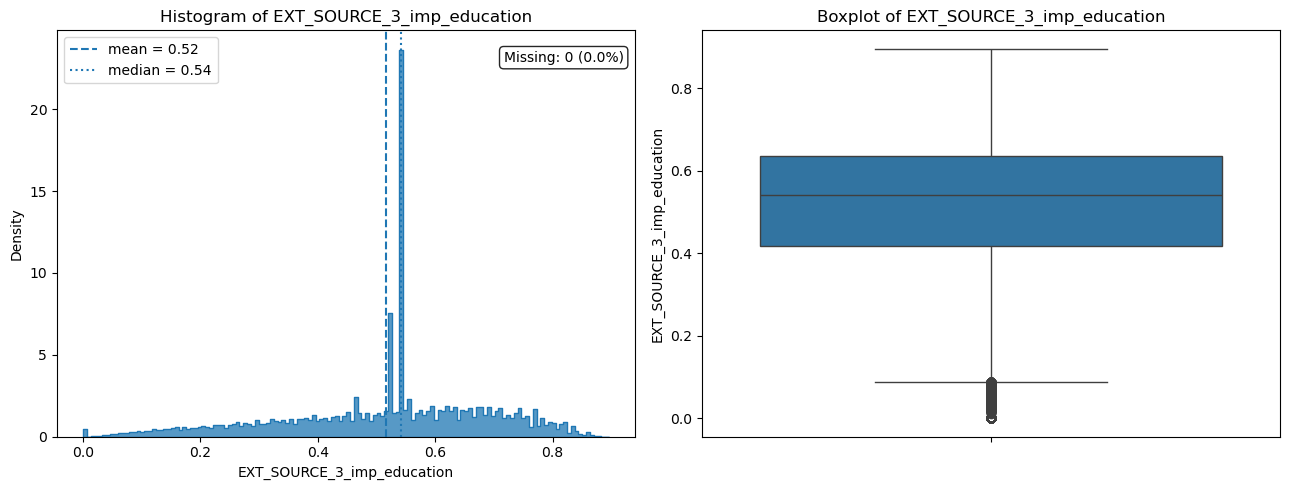

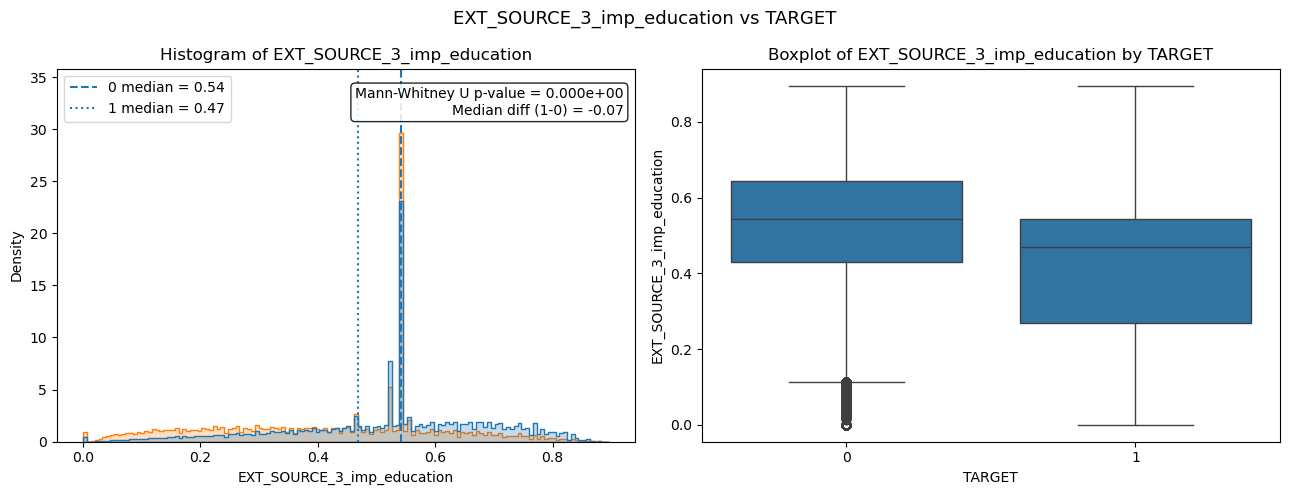

In [158]:
plot_quantitative_distribution(df=df_imp, quant_var='EXT_SOURCE_3_imp_education')
plot_quantitative_vs_binary(df=df_imp, quant_var='EXT_SOURCE_3_imp_education', target_var='TARGET')

Imputation my median in `NAME_EDUCATION_TYPE_grouped` groupes preserve the most difference in distribution.

In [159]:
# plot_quantitative_distribution(df=df_imp, quant_var='EXT_SOURCE_3_imp_education_type_gender')
# plot_quantitative_vs_binary(df=df_imp, quant_var='EXT_SOURCE_3_imp_education_type_gender', binary_var='TARGET')

In [160]:
# plot_quantitative_distribution(df=df_imp, quant_var='EXT_SOURCE_3_imp_occupation_type')
# plot_quantitative_vs_binary(df=df_imp, quant_var='EXT_SOURCE_3_imp_occupation_type', binary_var='TARGET')

In [161]:
# plot_quantitative_distribution(df=df_imp, quant_var='EXT_SOURCE_3_imp_occupation_type_gender')
# plot_quantitative_vs_binary(df=df_imp, quant_var='EXT_SOURCE_3_imp_occupation_type_gender', binary_var='TARGET')

In [162]:
# plot_quantitative_distribution(df=df_imp, quant_var='EXT_SOURCE_3_imp_occupation_education')
# plot_quantitative_vs_binary(df=df_imp, quant_var='EXT_SOURCE_3_imp_occupation_education', binary_var='TARGET')

In [163]:
# plot_quantitative_distribution(df=df_imp, quant_var='EXT_SOURCE_3_imp_occupation_education_gender')
# plot_quantitative_vs_binary(df=df_imp, quant_var='EXT_SOURCE_3_imp_occupation_education_gender', binary_var='TARGET')

In [164]:
# plot_quantitative_distribution(df=df_imp, quant_var='EXT_SOURCE_3_imp_income_occupation_education_gender')
# plot_quantitative_vs_binary(df=df_imp, quant_var='EXT_SOURCE_3_imp_income_occupation_education_gender', binary_var='TARGET')

In [165]:
# plot_quantitative_distribution(df=df_imp, quant_var='EXT_SOURCE_3_imp_gender')
# plot_quantitative_vs_binary(df=df_imp, quant_var='EXT_SOURCE_3_imp_gender', binary_var='TARGET')

In [166]:
# plot_quantitative_distribution(df=df_imp, quant_var='EXT_SOURCE_3_imp_gender_income')
# plot_quantitative_vs_binary(df=df_imp, quant_var='EXT_SOURCE_3_imp_gender_income', binary_var='TARGET')

In [167]:
# plot_quantitative_distribution(df=df_imp, quant_var='EXT_SOURCE_3_imp_gender_occupation')
# plot_quantitative_vs_binary(df=df_imp, quant_var='EXT_SOURCE_3_imp_gender_occupation', binary_var='TARGET')

In [168]:
# plot_quantitative_distribution(df=df_imp, quant_var='EXT_SOURCE_3_imp_education_occupation')
# plot_quantitative_vs_binary(df=df_imp, quant_var='EXT_SOURCE_3_imp_education_occupation', binary_var='TARGET')

In [169]:
# plot_quantitative_distribution(df=df_imp, quant_var='EXT_SOURCE_3_imp_education_occupation_gender')
# plot_quantitative_vs_binary(df=df_imp, quant_var='EXT_SOURCE_3_imp_education_occupation_gender', binary_var='TARGET')

In [170]:
# plot_quantitative_distribution(df=df_imp, quant_var='EXT_SOURCE_3_imp_organization')
# plot_quantitative_vs_binary(df=df_imp, quant_var='EXT_SOURCE_3_imp_organization', binary_var='TARGET')

In [171]:
# plot_quantitative_distribution(df=df_imp, quant_var='EXT_SOURCE_3_imp_organization_education')
# plot_quantitative_vs_binary(df=df_imp, quant_var='EXT_SOURCE_3_imp_organization_education', binary_var='TARGET')

In [172]:
# plot_quantitative_distribution(df=df_imp, quant_var='EXT_SOURCE_3_imp_education_organization')
# plot_quantitative_vs_binary(df=df_imp, quant_var='EXT_SOURCE_3_imp_education_organization', binary_var='TARGET')

In [173]:
# plot_quantitative_distribution(df=df_imp, quant_var='EXT_SOURCE_3_imp_organization_gender')
# plot_quantitative_vs_binary(df=df_imp, quant_var='EXT_SOURCE_3_imp_organization_gender', binary_var='TARGET')

In [174]:
# plot_quantitative_distribution(df=df_imp, quant_var='EXT_SOURCE_3_imp_gender_organization')
# plot_quantitative_vs_binary(df=df_imp, quant_var='EXT_SOURCE_3_imp_gender_organization', binary_var='TARGET')

In [175]:
binned_df, ext_source_3_summary = bin_quantitative_var(
    df = app_df,
    quant_var='EXT_SOURCE_3',
    quantiles_bins=True,
    target_var='TARGET',
    missing_as_category=True,
    return_binned_quantiles=False,
    return_summary=True,
    return_df=True
)

ext_source_3_summary

,feature,binned_column,binning_type,bin,count,share,n_target_1,n_target_0,target_rate
0,EXT_SOURCE_3,EXT_SOURCE_3_binned_quantiles,quantiles,Q1,49445,0.160791,8097,41348,0.163758
1,EXT_SOURCE_3,EXT_SOURCE_3_binned_quantiles,quantiles,Q2,49746,0.161770,4353,45393,0.087505
2,EXT_SOURCE_3,EXT_SOURCE_3_binned_quantiles,quantiles,Q3,49578,0.161224,2851,46727,0.057505
3,EXT_SOURCE_3,EXT_SOURCE_3_binned_quantiles,quantiles,Q4,49470,0.160872,2216,47254,0.044795
4,EXT_SOURCE_3,EXT_SOURCE_3_binned_quantiles,quantiles,Q5,48307,0.157090,1631,46676,0.033763
5,EXT_SOURCE_3,EXT_SOURCE_3_binned_quantiles,quantiles,Missing,60965,0.198253,5677,55288,0.093119


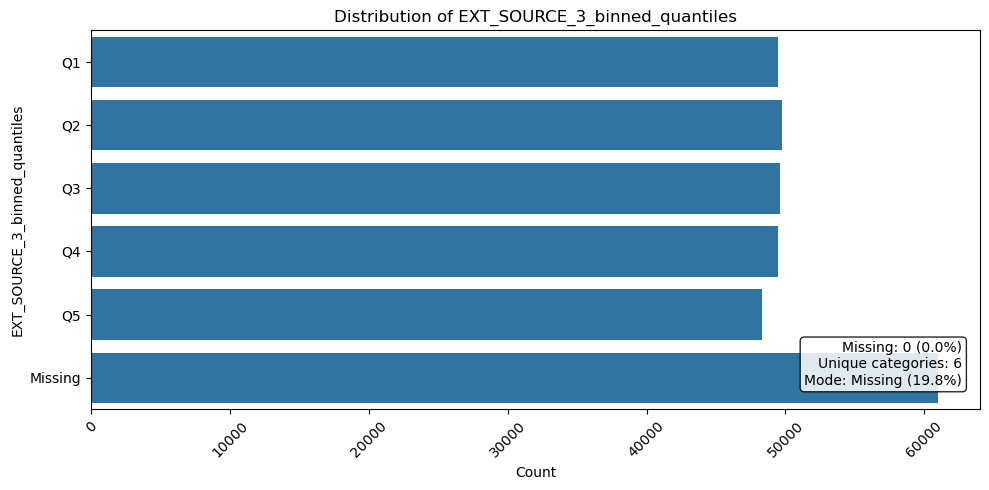

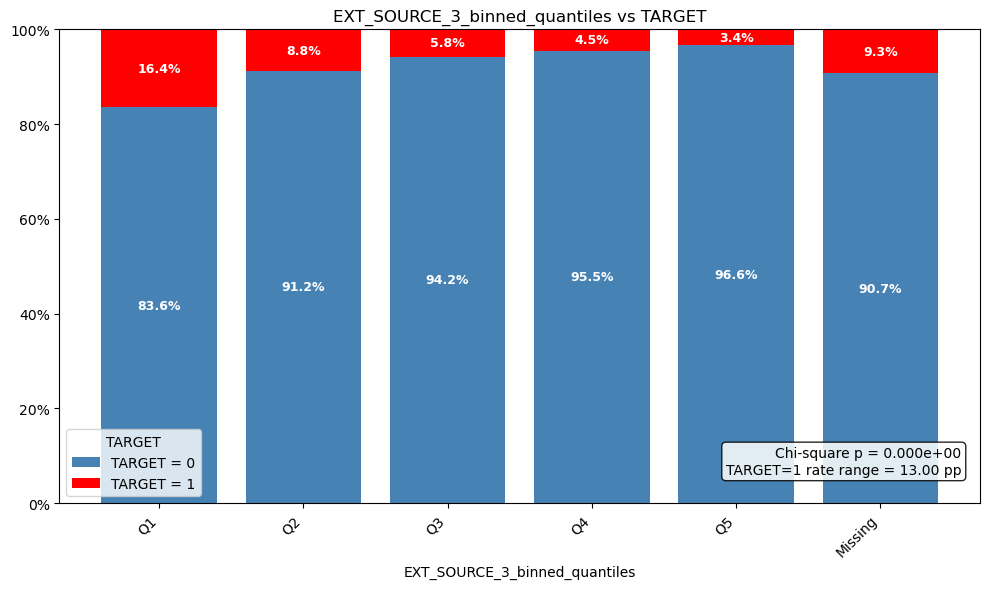

In [176]:
plot_categorical_distribution(df=binned_df, cat_var='EXT_SOURCE_3_binned_quantiles', respect_category_order=True)
plot_categorical_vs_binary(df=binned_df, cat_var='EXT_SOURCE_3_binned_quantiles', target_var='TARGET', respect_category_order=True)

In [177]:
binned_df, ext_source_3_imp_education_summary = bin_quantitative_var(
    df = df_imp,
    quant_var='EXT_SOURCE_3_imp_education',
    quantiles_bins=True,
    target_var='TARGET',
    missing_as_category=False,
    return_binned_quantiles=False,
    return_summary=True,
    return_df=True
)

ext_source_3_imp_education_summary

,feature,binned_column,binning_type,bin,count,share,n_target_1,n_target_0,target_rate
0,EXT_SOURCE_3_imp_education,EXT_SOURCE_3_imp_education_binned_quantiles,quantiles,Q1,61993,0.201596,9334,52659,0.150565
1,EXT_SOURCE_3_imp_education,EXT_SOURCE_3_imp_education_binned_quantiles,quantiles,Q2,72108,0.234489,5291,66817,0.073376
2,EXT_SOURCE_3_imp_education,EXT_SOURCE_3_imp_education_binned_quantiles,quantiles,Q3,52295,0.170059,5057,47238,0.096701
3,EXT_SOURCE_3_imp_education,EXT_SOURCE_3_imp_education_binned_quantiles,quantiles,Q4,60124,0.195518,2994,57130,0.049797
4,EXT_SOURCE_3_imp_education,EXT_SOURCE_3_imp_education_binned_quantiles,quantiles,Q5,60991,0.198338,2149,58842,0.035235


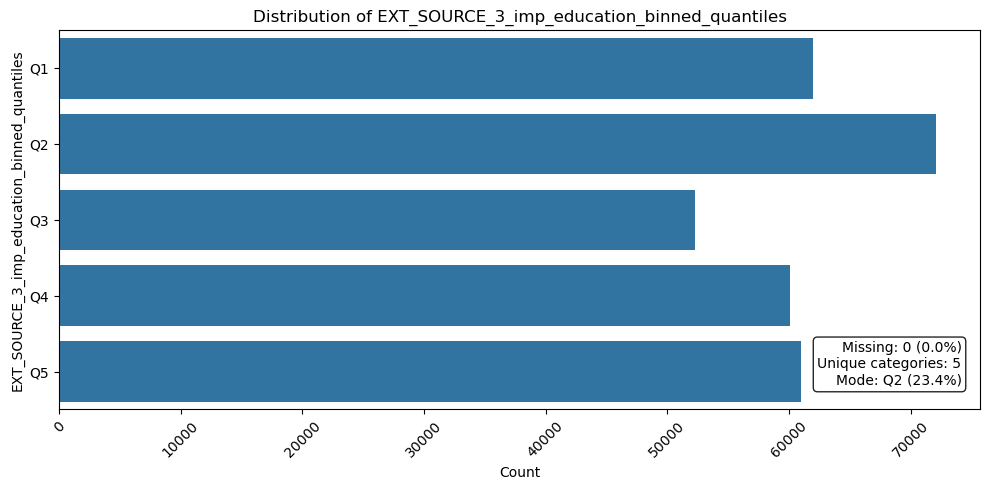

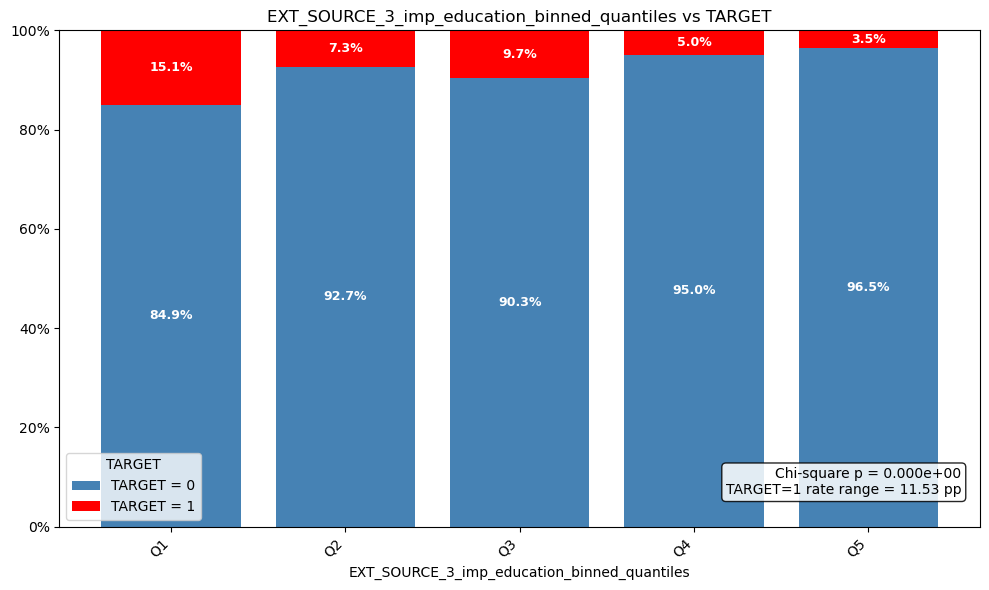

In [178]:
plot_categorical_distribution(df=binned_df, cat_var='EXT_SOURCE_3_imp_education_binned_quantiles', respect_category_order=True)
plot_categorical_vs_binary(df=binned_df, cat_var='EXT_SOURCE_3_imp_education_binned_quantiles', target_var='TARGET', respect_category_order=True)

## 4. Application financial and material summary
Variables that should be used as predictors
- EXT_SOURCE_1_missing
- EXT_SOURCE_1_imp_income_type_gender
- EXT_SOURCE_1_binned_quantiles
- EXT_SOURCE_1_imp_income_type_gender_binned_quantiles
- EXT_SOURCE_2
- EXT_SOURCE_2_binned_quantiles
- EXT_SOURCE_3_missing
- EXT_SOURCE_3_imp_education
- EXT_SOURCE_3_binned_quantiles
- EXT_SOURCE_3_imp_education_binned_quantiles